## The training and testing accuracies of the eight selected classifiers are illustrated.

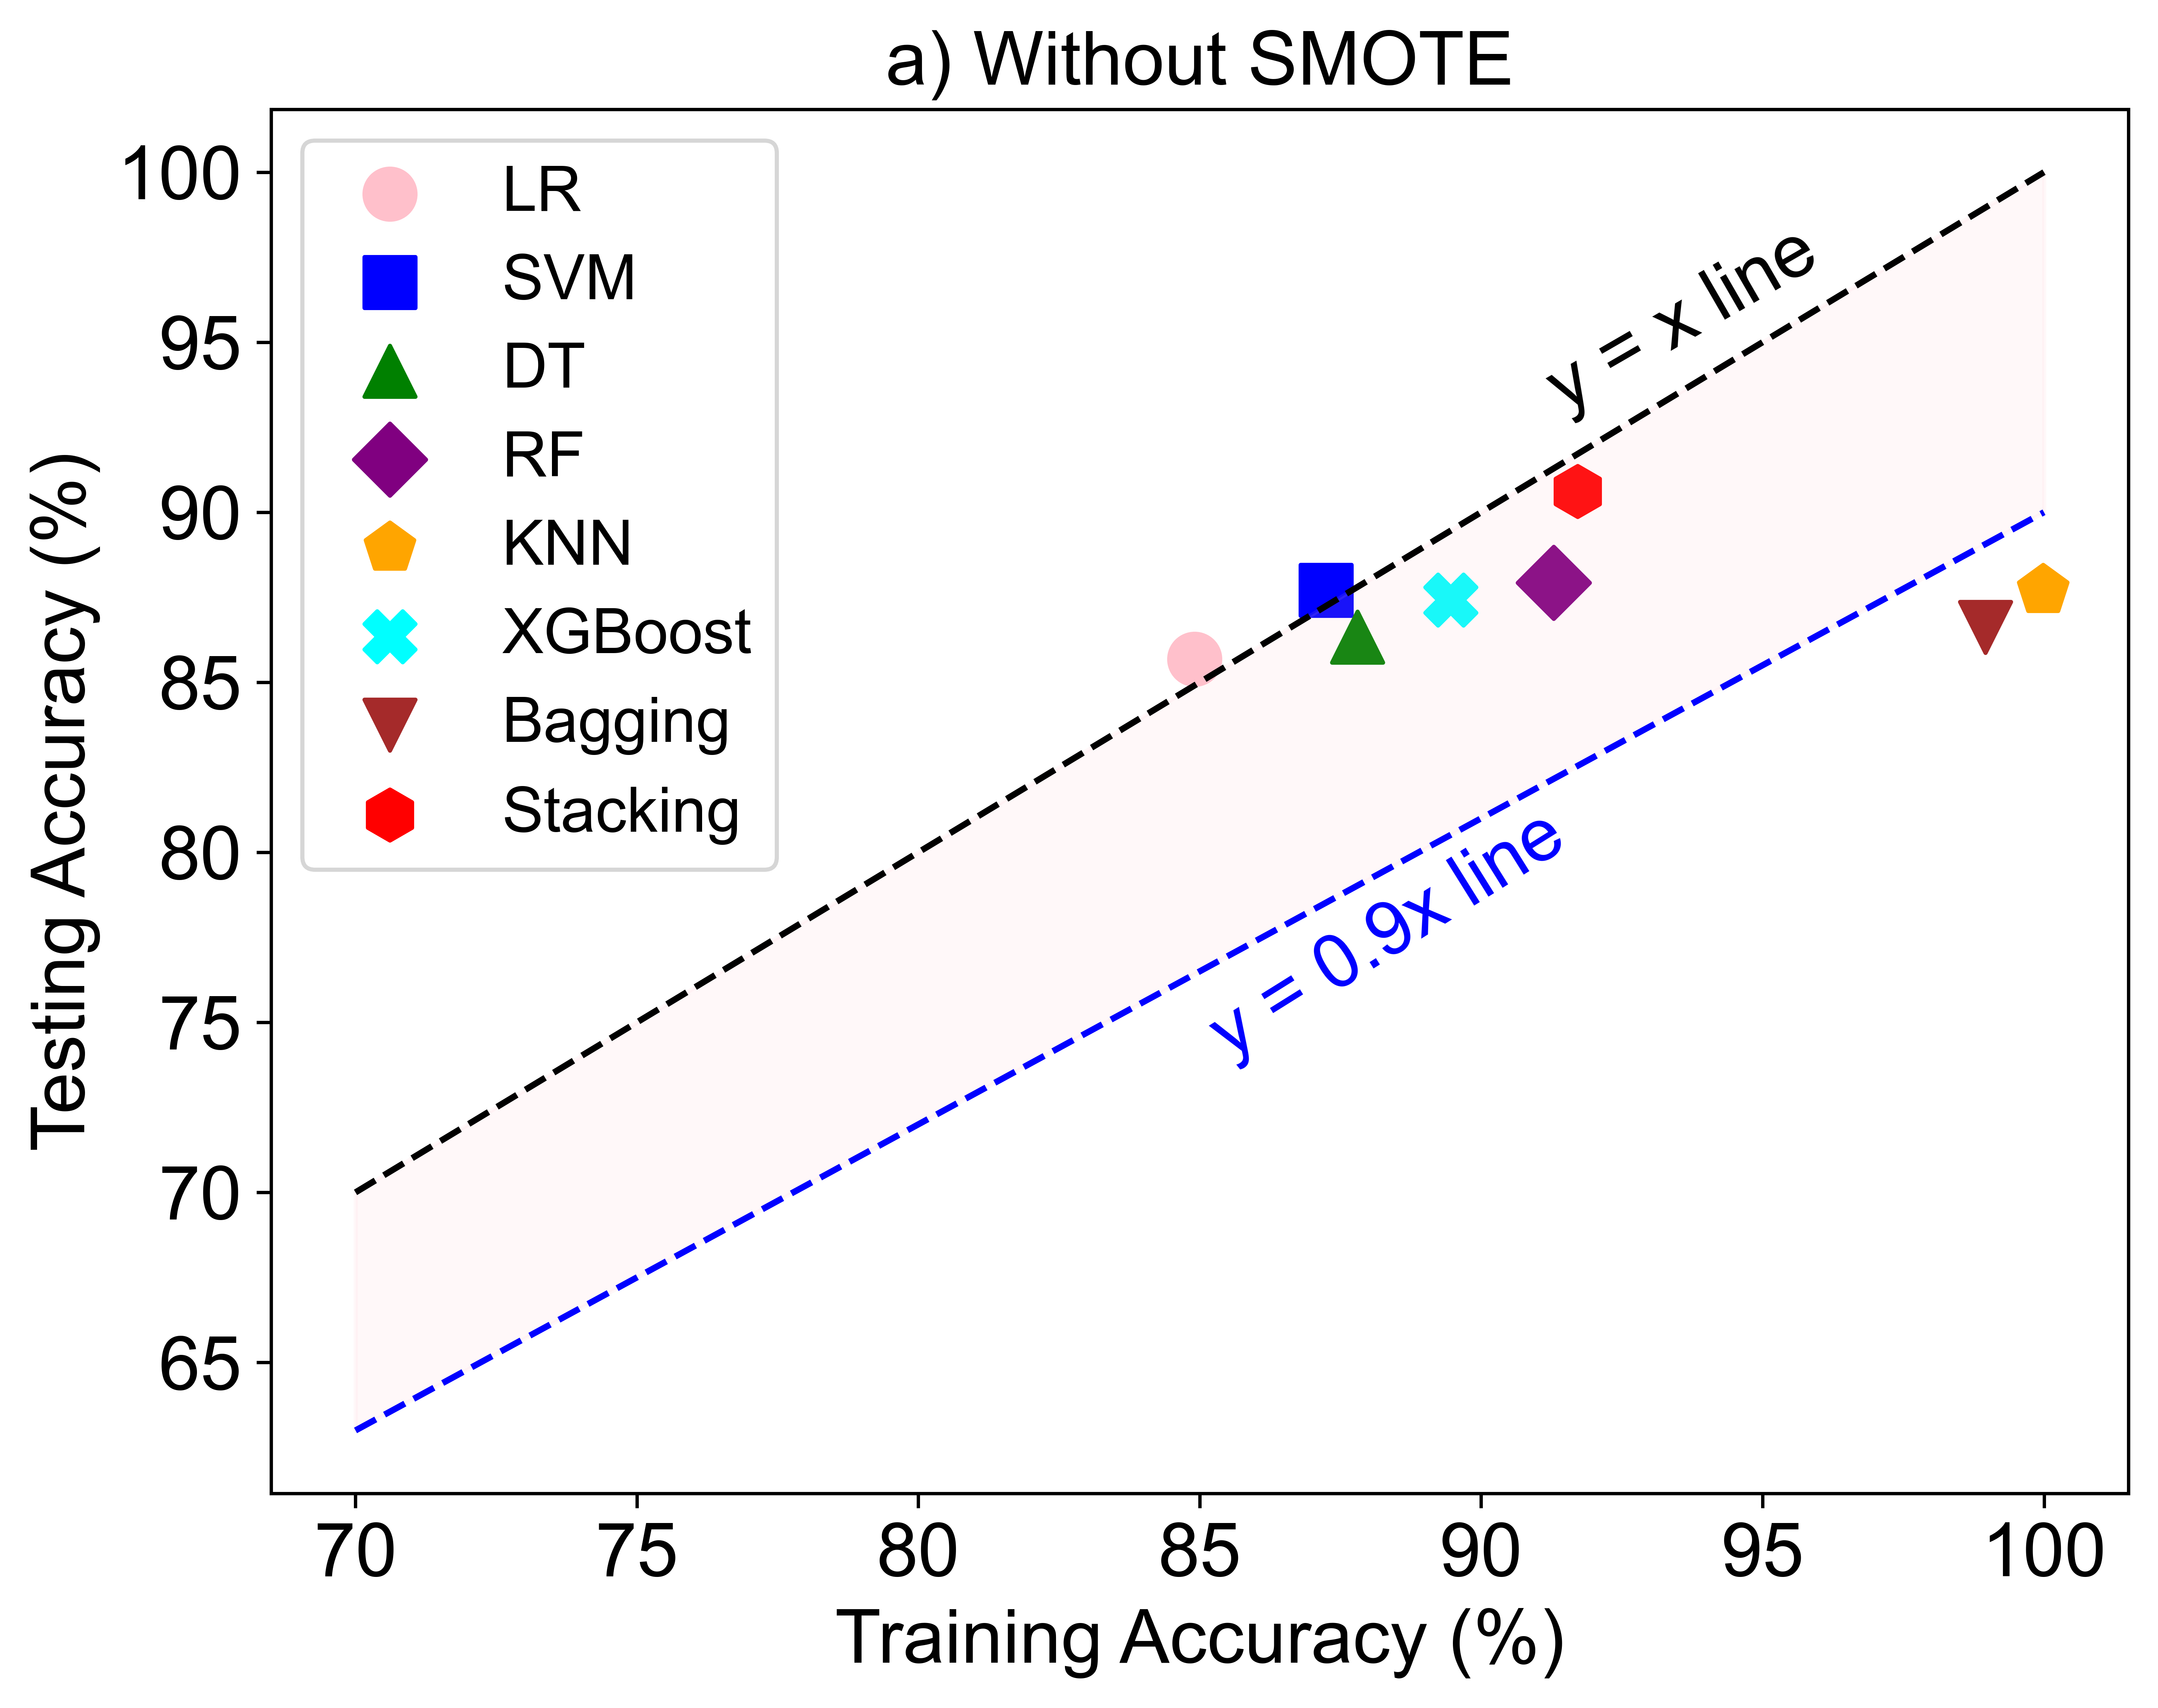

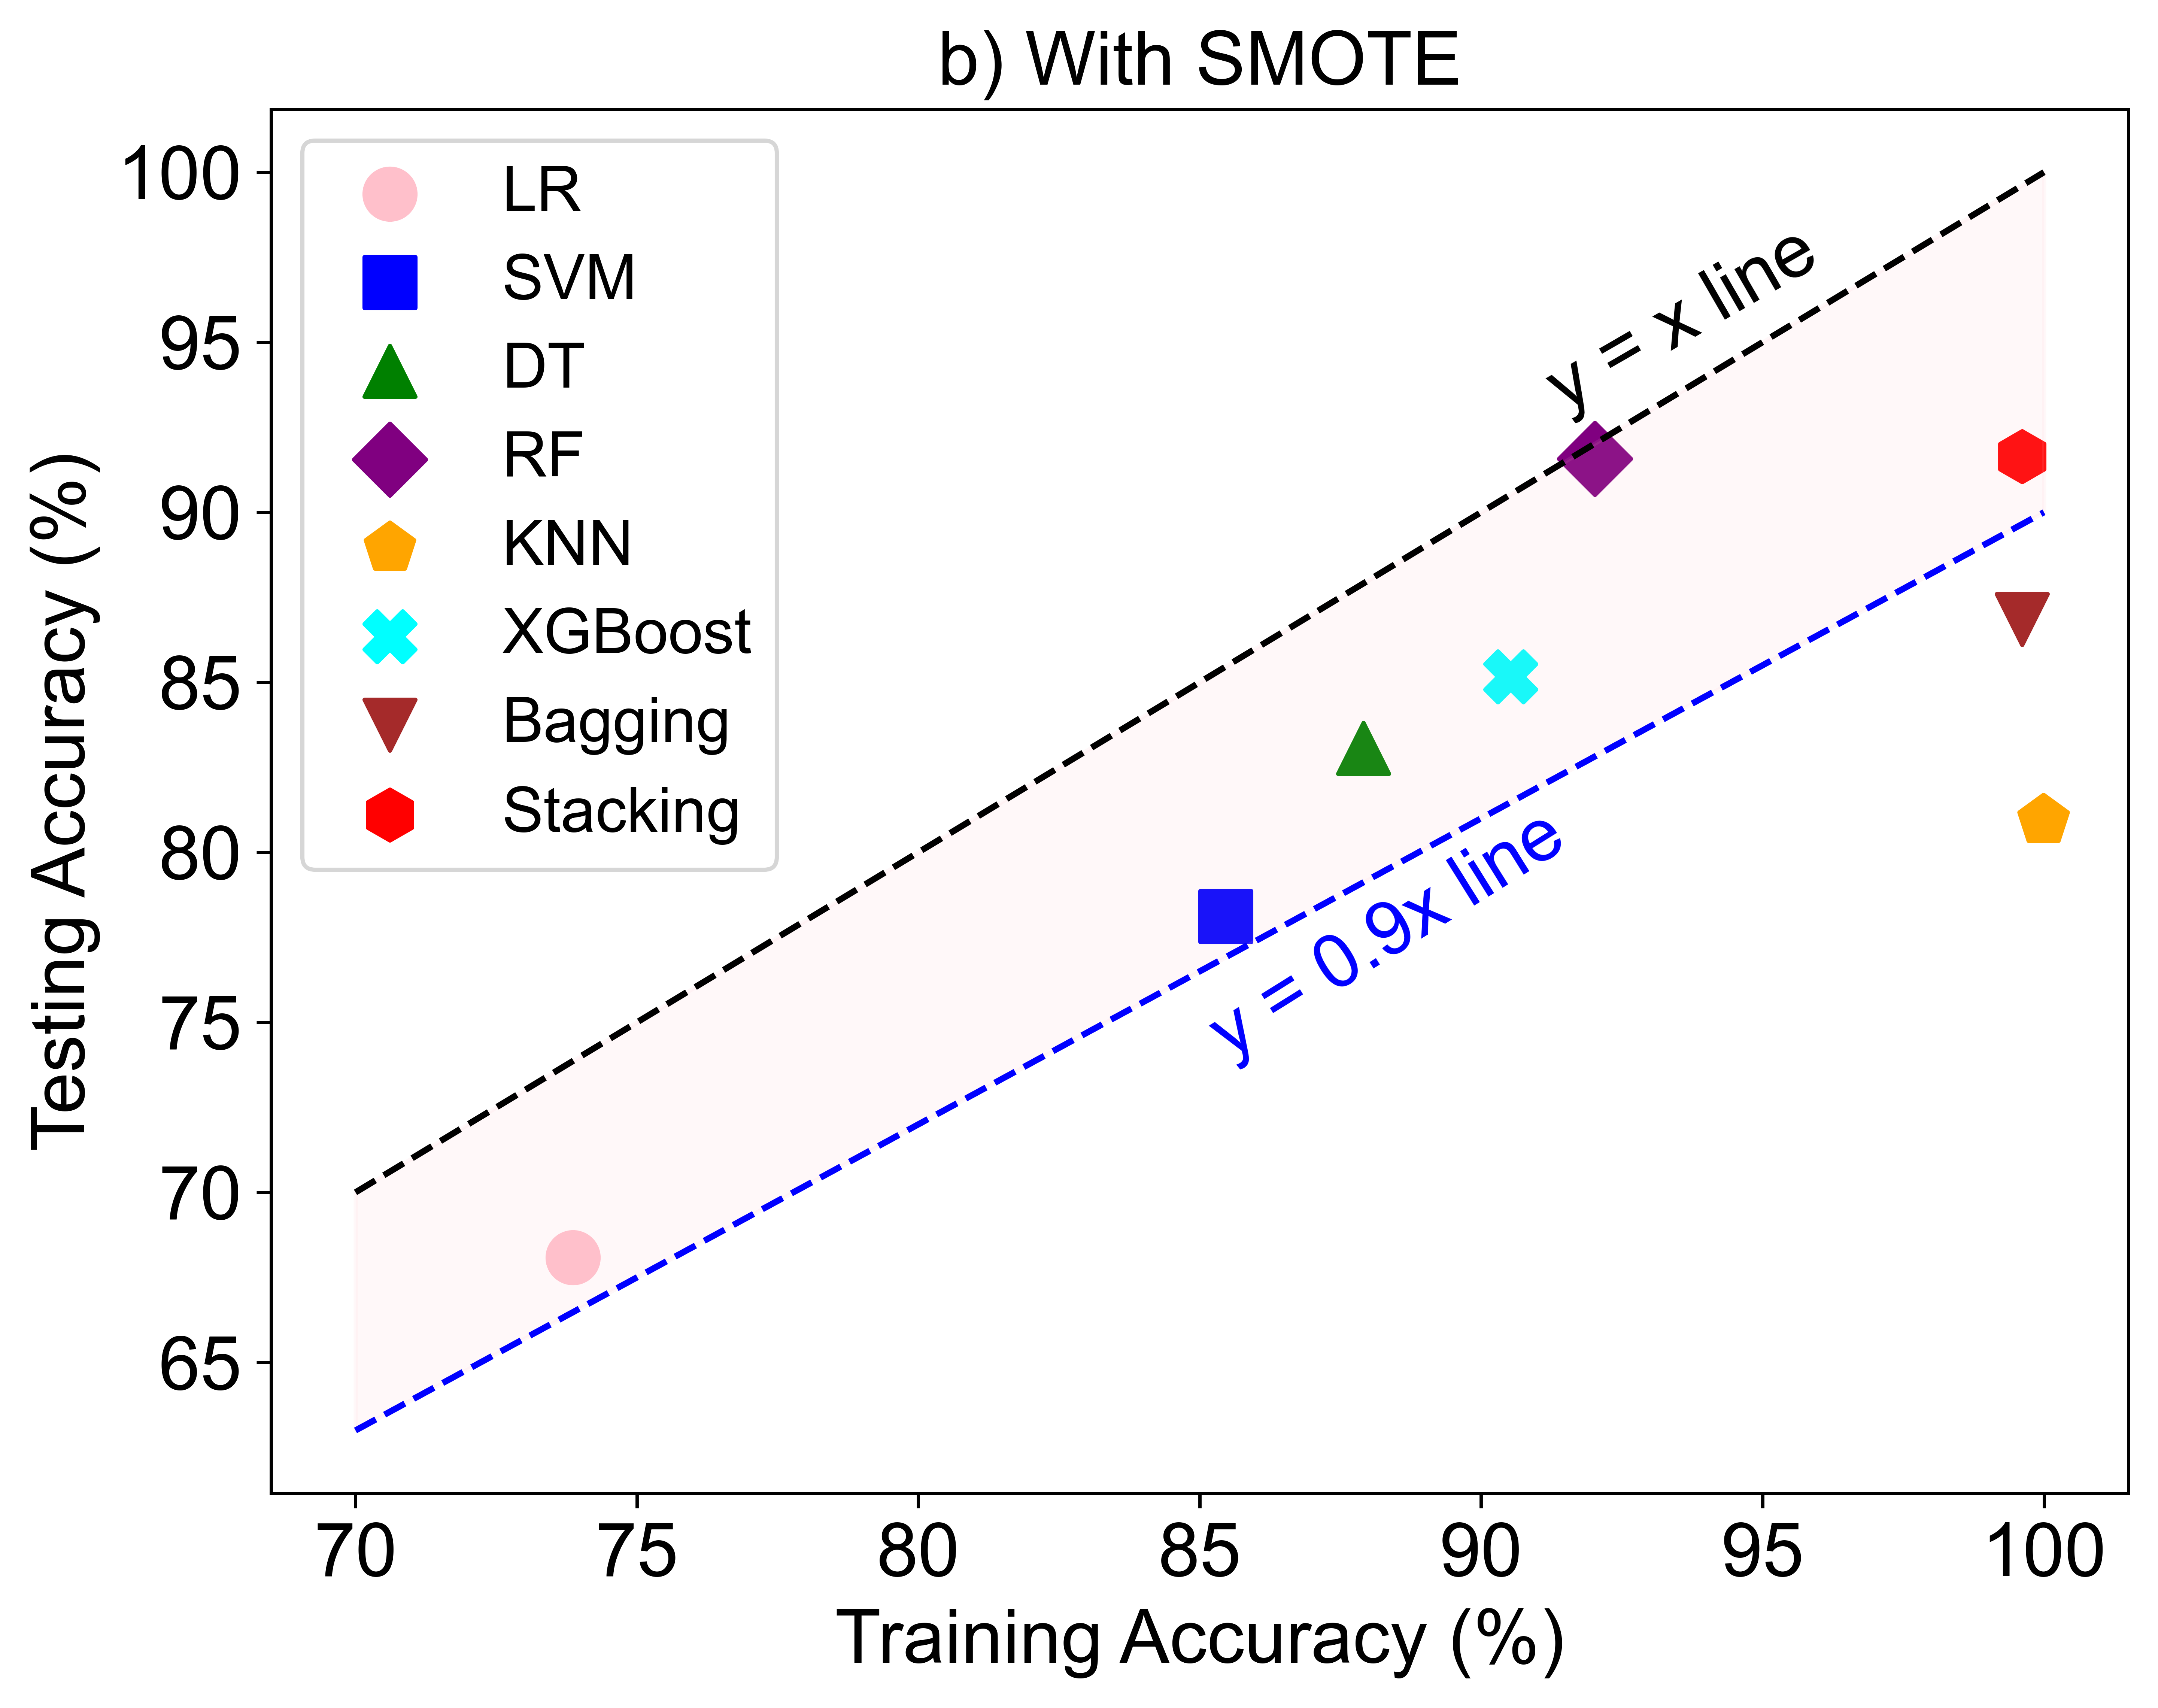

In [2]:
# Importing the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set font globally
plt.rcParams['font.family'] = 'Arial'

def plot_accuracy_scatter(sheet_name, title, save_path=None):
    # Load data
    df = pd.read_excel('Performance Comparison.xlsx', sheet_name=sheet_name)
    
    # Extract classifier names and accuracies
    classifier_names = df['Classifier'].tolist()
    test_accuracies = df['Testing Accuracy'].div(100).tolist()
    train_accuracies = df['Training Accuracy'].div(100).tolist()
    
    # Classifier style mapping inside the function
    class_style_mapping = {
        'LR': {'color': 'pink', 'marker': 'o', 'size': 150},
        'SVM': {'color': 'blue', 'marker': 's', 'size': 150},
        'DT': {'color': 'green', 'marker': '^', 'size': 150},
        'RF': {'color': 'purple', 'marker': 'D', 'size': 150},
        'KNN': {'color': 'orange', 'marker': 'p', 'size': 150},
        'XGBoost': {'color': 'cyan', 'marker': 'X', 'size': 150},
        'Bagging': {'color': 'brown', 'marker': 'v', 'size': 150},
        'Stacking': {'color': 'red', 'marker': 'h', 'size': 150},
    }
    
    # Create figure
    plt.figure(figsize=(8, 6), dpi=800)
    legend_handles = []
    
    # Plot scatter points
    for classifier_name, (test_acc, train_acc) in zip(classifier_names, zip(test_accuracies, train_accuracies)):
        style_params = class_style_mapping[classifier_name]
        scatter = plt.scatter(train_acc * 100, test_acc * 100,
                              s=style_params['size'],
                              marker=style_params['marker'],
                              color=style_params['color'])
        legend_handles.append(scatter)
    
    # Plot y=x and y=0.9x lines
    x_values = np.linspace(70, 100, 100)
    plt.plot([70, 100], [70, 100], '--', color='black', linewidth=1.5)
    plt.plot(x_values, 0.9 * x_values, '--', color='blue', linewidth=1.5)
    plt.fill_between(x_values, 0.9*x_values, x_values, color='pink', alpha=0.1)
    
    # Annotations
    plt.text(91, 93, 'y = x line', fontsize=18, color='black', rotation=30)
    plt.text(85, 74, 'y = 0.9x line', fontsize=18, color='blue', rotation=32)
    
    # Title, labels, ticks, legend
    plt.title(title, fontsize=18)
    plt.xlabel('Training Accuracy (%)', fontsize=18)
    plt.ylabel('Testing Accuracy (%)', fontsize=18)
    plt.tick_params(axis='both', labelsize=18)
    plt.legend(handles=legend_handles, labels=classifier_names, loc='upper left', fontsize=15)
    
    # Save figure
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    
    # Show plot
    plt.show()

# Plot both sheets
plot_accuracy_scatter('data without SMOTE', 'a) Without SMOTE', save_path='Performance Comparison Without_SMOTE.png')
plot_accuracy_scatter('data SMOTE', 'b) With SMOTE', save_path='Performance Comparison With_SMOTE.png')

## Two threshold lines are used to demonstrate the relationship between the testing and training accuracies.
-The ideal situation is expressed when y=x line, where the testing and training outputs are equal.

-The line y=0.9x  indicates that the testing accuracy should be at least 90% of the training accuracy, suggesting that the training
accuracy of the classifier is not greater than the 10% of testing accuracy results.
##  The results indicate that the testing prediction accuracy of the classifiers is strongly correlated with the training accuracy.
-In without SMOTE case: DT, 
XGBoost, RF, and stacking classifier.

-In with SMOTE case: LR, SVM, DT, 
XGBoost, RF, and stacking classifier.s
